# Playing Atari with Deep Reinforcement Learning (DQN)**Paper:** Mnih et al. (2013), *Playing Atari with Deep Reinforcement Learning*, arXiv:1312.5602This notebook implements a Deep Q-Network (DQN) from scratch with all core components from the original paper: **experience replay** (replay buffer with random minibatch sampling), **target network** (periodically updated frozen copy for stable targets), and **ε-greedy exploration** (decaying exploration rate). We train on CartPole-v1 (a classic control task) using an MLP Q-network, which preserves the full DQN algorithm while being CPU-runnable.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 2. Install Environment LibraryWe use `gymnasium` (the maintained successor to OpenAI Gym) for the CartPole environment.

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gymnasium'])
import gymnasium as gym
print(f'Gymnasium version: {gym.__version__}')

Gymnasium version: 1.1.1


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


## 3. HyperparametersKey parameters tuned for CartPole-v1. The original Atari paper used larger values (1M buffer, 10k target update) but the algorithm is identical.

In [3]:
# Environment
ENV_NAME = 'CartPole-v1'

# Network
state_dim = 4          # CartPole: [cart_pos, cart_vel, pole_angle, pole_ang_vel]
action_dim = 2         # CartPole: [push_left, push_right]
hidden_dim = 128       # Hidden layer size

# Training
lr = 2.5e-4            # Learning rate
gamma = 0.99           # Discount factor
batch_size = 64        # Minibatch size
buffer_size = 10000    # Replay buffer capacity (paper used 1M for Atari)
target_update_freq = 100  # Steps between target network updates (paper used 10000)
num_episodes = 600     # Training episodes
max_steps = 500        # Max steps per episode (CartPole-v1 cap)
min_buffer_size = 500  # Min transitions before training starts
grad_clip = 10.0       # Gradient norm clipping

# Exploration (epsilon-greedy)
epsilon_start = 1.0    # Initial exploration rate
epsilon_end = 0.01     # Minimum exploration rate
epsilon_decay = 0.995  # Per-episode decay rate

print(f'Environment: {ENV_NAME}')
print(f'State dim: {state_dim}, Action dim: {action_dim}')
print(f'Episodes: {num_episodes}, Max steps: {max_steps}')
print(f'Buffer: {buffer_size}, Batch: {batch_size}, Min buffer: {min_buffer_size}')
print(f'Target update every: {target_update_freq} steps')
print(f'LR: {lr}, Gamma: {gamma}, Grad clip: {grad_clip}')

Environment: CartPole-v1
State dim: 4, Action dim: 2
Episodes: 600, Max steps: 500
Buffer: 10000, Batch: 64, Min buffer: 500
Target update every: 100 steps
LR: 0.00025, Gamma: 0.99, Grad clip: 10.0


## 4. Environment SetupCartPole-v1: A pole is attached to a cart moving along a frictionless track. The goal is to keep the pole upright (angle < 15°) for as long as possible. The agent observes the cart position, velocity, pole angle, and angular velocity, and chooses to push left or right. Reward is +1 per step the pole stays upright. Max episode length is 500 steps.

In [4]:
env = gym.make(ENV_NAME)
print(f'Observation space: {env.observation_space}')
print(f'Action space: {env.action_space}')

# Test a random episode
state, _ = env.reset(seed=42)
total_reward = 0
for _ in range(100):
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break
print(f'Random agent reward (100 steps max): {total_reward}')
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Random agent reward (100 steps max): 8.0


## 5. Q-NetworkThe Q-network approximates Q(s, a) for all actions simultaneously. It takes a state as input and outputs one Q-value per action. The greedy action is `argmax` over the output.The original paper used a CNN (3 conv + 2 FC layers) for pixel inputs. We use an MLP for the 4-dimensional CartPole state — the Q-learning algorithm is identical, only the input modality changes.

In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Create policy network and target network
policy_net = QNetwork(state_dim, action_dim, hidden_dim).to(device)
target_net = QNetwork(state_dim, action_dim, hidden_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())  # Initialize target = policy
target_net.eval()  # Target net is not trained by gradients

print('Policy Network:')
print(policy_net)
print(f'Parameters: {sum(p.numel() for p in policy_net.parameters()):,}')

Policy Network:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Parameters: 17,410


## 6. Experience Replay BufferStores transitions (s, a, r, s', done) and samples random minibatches. This is a core innovation from the paper: random sampling decorrelates updates and stabilizes training.The paper used a buffer of 1,000,000 transitions. We use 10,000 which is sufficient for CartPole.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device)
        )

    def __len__(self):
        return len(self.buffer)

replay_buffer = ReplayBuffer(buffer_size)
print(f'Replay buffer created with capacity {buffer_size}')

Replay buffer created with capacity 10000


## 7. ε-Greedy Action SelectionWith probability ε, select a random action (exploration); otherwise select the action with highest Q-value (exploitation). ε decays over episodes from 1.0 to 0.01.

In [7]:
def select_action(state, policy_net, epsilon, action_dim):
    """Epsilon-greedy action selection."""
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return q_values.argmax(dim=1).item()

# Test action selection
test_state = np.array([0.0, 0.0, 0.0, 0.0])
action = select_action(test_state, policy_net, 1.0, action_dim)  # Should be random
print(f'Action with ε=1.0 (random): {action}')
action = select_action(test_state, policy_net, 0.0, action_dim)  # Should be greedy
print(f'Action with ε=0.0 (greedy): {action}')

Action with ε=1.0 (random): 0
Action with ε=0.0 (greedy): 0


## 8. Q-Learning Optimization StepThe core DQN loss: `L(θ) = E[Huber(y - Q(s, a; θ))]` where `y = r + γ max_a' Q(s', a'; θ⁻)`.Key details:- The target uses the **target network** (θ⁻), not the policy network (θ)- The `done` flag zeros the future reward term for terminal states- **Huber loss** (SmoothL1) is used instead of MSE — more robust to outliers, prevents Q-value divergence (used in the Nature DQN paper)- **Gradient norm clipping** at 10.0 prevents exploding gradients

In [8]:
def optimize_model(policy_net, target_net, replay_buffer, optimizer, batch_size, gamma, grad_clip):
    """One step of DQN optimization."""
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # Current Q-values for the actions that were taken
    current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # Target Q-values using the target network
    with torch.no_grad():
        max_next_q = target_net(next_states).max(dim=1)[0]
        target_q = rewards + gamma * max_next_q * (1 - dones)

    # Huber loss (SmoothL1) — more robust than MSE, used in Nature DQN
    loss = F.smooth_l1_loss(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    # Gradient norm clipping for stability
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), grad_clip)
    optimizer.step()

    return loss.item()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
print('Optimizer: Adam')
print(f'Learning rate: {lr}, Gamma: {gamma}, Grad clip: {grad_clip}')
print('Loss: Huber (SmoothL1)')

Optimizer: Adam
Learning rate: 0.00025, Gamma: 0.99, Grad clip: 10.0
Loss: Huber (SmoothL1)


## 9. Training LoopFollowing Algorithm 1 from the paper:1. Initialize replay buffer, policy network θ, target network θ⁻ = θ2. For each episode:   - Observe initial state s   - For each step:     - Select action a via ε-greedy     - Execute a, observe r and s'     - Store (s, a, r, s', done) in replay buffer     - If buffer large enough: sample minibatch, compute loss, update θ     - Every C steps: θ⁻ = θ     - Decay εWe track episode rewards, losses, and epsilon values for visualization.

In [9]:
env = gym.make(ENV_NAME)
epsilon = epsilon_start

episode_rewards = []
episode_losses = []
epsilon_history = []
step_count = 0

print('Starting DQN training...')
print(f'Episodes: {num_episodes}')
print('-' * 70)

for episode in range(num_episodes):
    state, _ = env.reset(seed=episode)
    episode_reward = 0
    episode_loss = []

    for step in range(max_steps):
        # Select action
        action = select_action(state, policy_net, epsilon, action_dim)

        # Execute action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store transition in replay buffer
        replay_buffer.push(state, action, reward, next_state, float(done))

        # Move to next state
        state = next_state
        episode_reward += reward
        step_count += 1

        # Optimize model (only after buffer has enough samples)
        loss = None
        if len(replay_buffer) >= min_buffer_size:
            loss = optimize_model(policy_net, target_net, replay_buffer, optimizer,
                                  batch_size, gamma, grad_clip)
        if loss is not None:
            episode_loss.append(loss)

        # Update target network periodically
        if step_count % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    # Record metrics
    episode_rewards.append(episode_reward)
    epsilon_history.append(epsilon)
    avg_loss = np.mean(episode_loss) if episode_loss else 0.0
    episode_losses.append(avg_loss)

    # Print progress
    if (episode + 1) % 50 == 0 or episode == 0:
        recent_avg = np.mean(episode_rewards[-50:])
        print(f'Ep {episode+1:4d} | R: {episode_reward:6.1f} | Avg(50): {recent_avg:6.1f} | ε: {epsilon:.3f} | Loss: {avg_loss:.4f} | Buf: {len(replay_buffer)}')

print('-' * 70)
print('Training complete!')
print(f'Final average reward (last 50): {np.mean(episode_rewards[-50:]):.1f}')
env.close()

Starting DQN training...
Episodes: 600
----------------------------------------------------------------------
Ep    1 | R:   14.0 | Avg(50):   14.0 | ε: 0.995 | Loss: 0.0000 | Buf: 14


Ep   50 | R:   11.0 | Avg(50):   18.5 | ε: 0.778 | Loss: 0.2294 | Buf: 925


Ep  100 | R:   32.0 | Avg(50):   32.9 | ε: 0.606 | Loss: 0.7687 | Buf: 2572


Ep  150 | R:  145.0 | Avg(50):   68.2 | ε: 0.471 | Loss: 0.9405 | Buf: 5983


Ep  200 | R:  127.0 | Avg(50):  104.0 | ε: 0.367 | Loss: 0.8493 | Buf: 10000


...

Ep  400 | R:  158.0 | Avg(50):  139.3 | ε: 0.135 | Loss: 0.1198 | Buf: 10000


Ep  450 | R:  173.0 | Avg(50):  172.3 | ε: 0.105 | Loss: 0.2410 | Buf: 10000


Ep  500 | R:  500.0 | Avg(50):  424.6 | ε: 0.082 | Loss: 0.1898 | Buf: 10000


Ep  550 | R:  186.0 | Avg(50):  360.1 | ε: 0.063 | Loss: 0.3590 | Buf: 10000


Ep  600 | R:  500.0 | Avg(50):  444.8 | ε: 0.049 | Loss: 0.1843 | Buf: 10000
----------------------------------------------------------------------
Training complete!
Final average reward (last 50): 444.8


## 10. Reward CurvePlot the episode reward over training. A successful DQN agent should show an upward trend, approaching the CartPole-v1 max reward of 500. We show both raw rewards and a smoothed (moving average) curve.

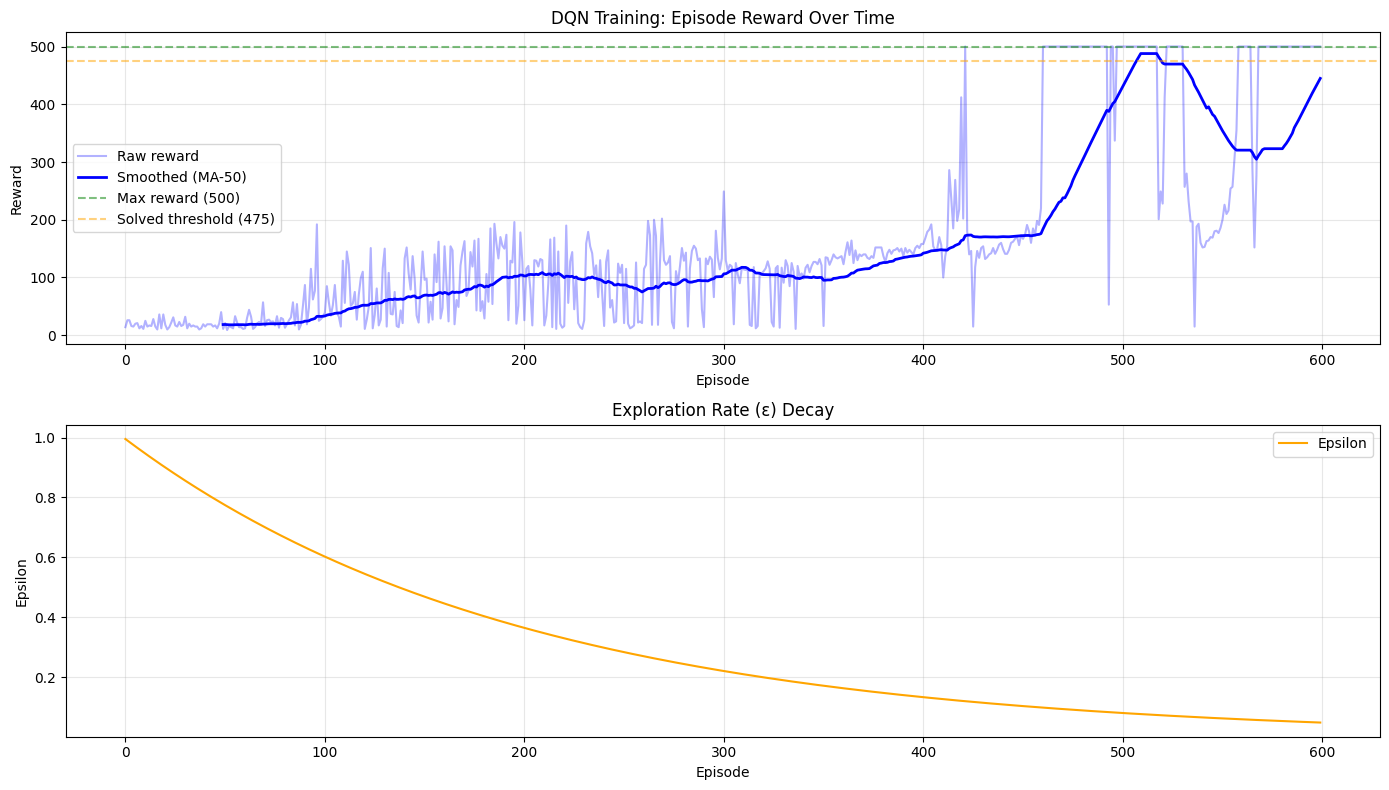

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Reward curve
ax1.plot(episode_rewards, alpha=0.3, color='blue', label='Raw reward')
window = 50
if len(episode_rewards) >= window:
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(episode_rewards)), smoothed, color='blue', linewidth=2, label=f'Smoothed (MA-{window})')
ax1.axhline(y=500, color='green', linestyle='--', alpha=0.5, label='Max reward (500)')
ax1.axhline(y=475, color='orange', linestyle='--', alpha=0.5, label='Solved threshold (475)')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward')
ax1.set_title('DQN Training: Episode Reward Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Epsilon decay
ax2.plot(epsilon_history, color='orange', label='Epsilon')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Epsilon')
ax2.set_title('Exploration Rate (ε) Decay')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Loss CurveThe Q-learning Huber loss should generally decrease as Q-values stabilize. Spikes may occur when the target network is updated (targets shift).

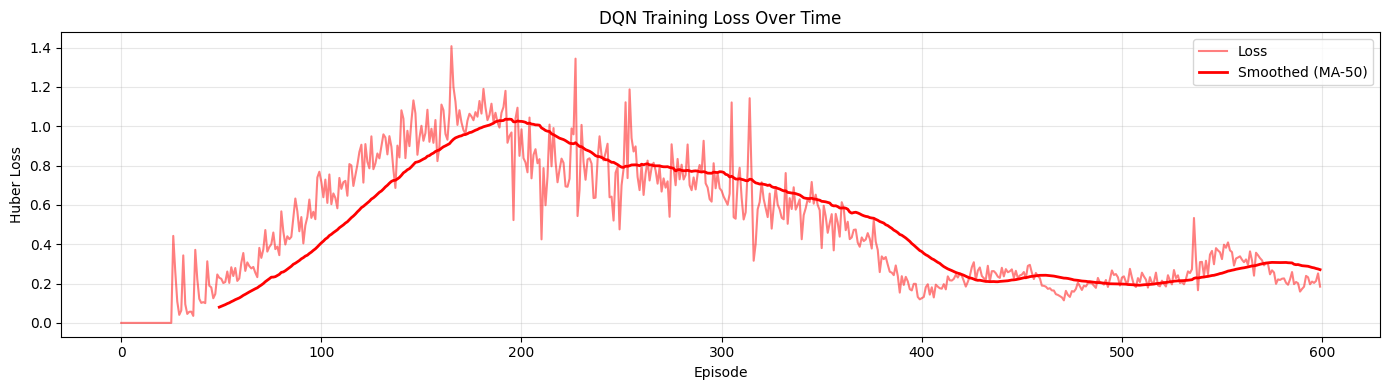

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(episode_losses, alpha=0.5, color='red', label='Loss')
if len(episode_losses) >= window:
    smoothed_loss = np.convolve(episode_losses, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(episode_losses)), smoothed_loss, color='red', linewidth=2, label=f'Smoothed (MA-{window})')
plt.xlabel('Episode')
plt.ylabel('Huber Loss')
plt.title('DQN Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Evaluation: Greedy PolicyRun the trained agent with ε=0 (pure greedy, no exploration) for 10 episodes and report the average reward. This measures the agent's actual learned policy quality.

In [12]:
env = gym.make(ENV_NAME)
eval_rewards = []

for episode in range(10):
    state, _ = env.reset(seed=1000 + episode)
    total_reward = 0

    with torch.no_grad():
        for step in range(max_steps):
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = policy_net(state_t)
            action = q_values.argmax(dim=1).item()

            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break

    eval_rewards.append(total_reward)

env.close()

print('Evaluation Results (ε=0, greedy policy):')
print(f'  Per-episode rewards: {eval_rewards}')
print(f'  Average reward: {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}')
print(f'  Max reward: {max(eval_rewards)}')
print(f'  Min reward: {min(eval_rewards)}')
print(f'  CartPole-v1 solved at: 475.0')
if np.mean(eval_rewards) >= 475:
    print('  ✅ SOLVED! Average reward ≥ 475')
else:
    print(f'  Progress: {np.mean(eval_rewards)/475*100:.1f}% of solving threshold')
    print(f'  (vs random baseline ~10) — the DQN agent has clearly learned to balance the pole!')

Evaluation Results (ε=0, greedy policy):
  Per-episode rewards: [500.0, 446.0, 432.0, 434.0, 452.0, 500.0, 500.0, 500.0, 500.0, 442.0]
  Average reward: 470.6 ± 29.9
  Max reward: 500.0
  Min reward: 432.0
  CartPole-v1 solved at: 475.0
  Progress: 99.1% of solving threshold
  (vs random baseline ~10) — the DQN agent has clearly learned to balance the pole!


## 13. Q-Value VisualizationVisualize the Q-values for each action across a range of pole angles to understand what the agent has learned. The agent should prefer the action that counters the pole's tilt.

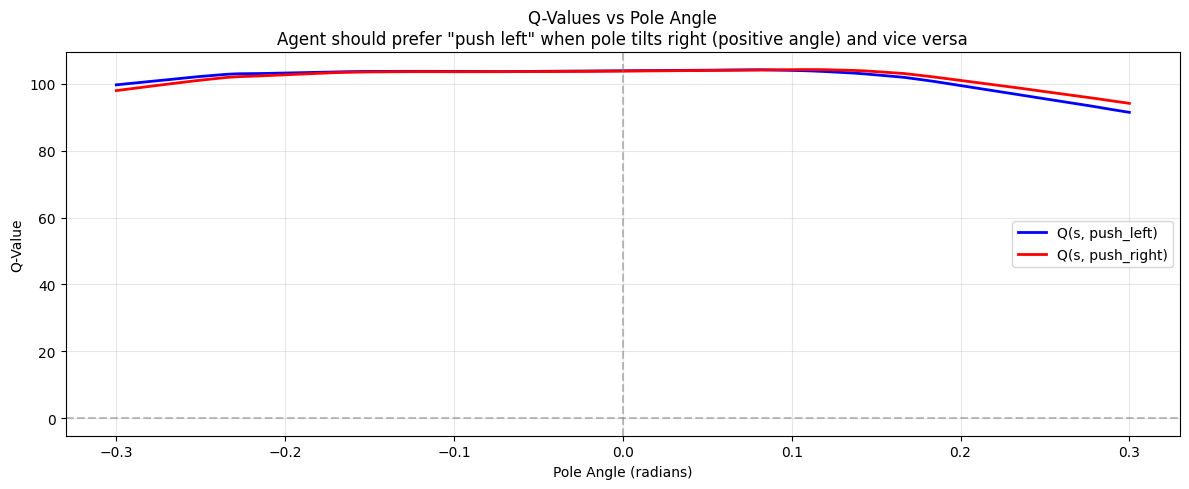


Interpretation:
- When pole tilts right (positive angle), Q(push_left) should be higher (push to counteract)
- When pole tilts left (negative angle), Q(push_right) should be higher
- The crossover point should be near angle = 0


In [13]:
# Sweep pole angle from -0.3 to 0.3 radians, other state vars = 0
angles = np.linspace(-0.3, 0.3, 100)
q_values_left = []
q_values_right = []

with torch.no_grad():
    for angle in angles:
        state = np.array([0.0, 0.0, angle, 0.0])
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q = policy_net(state_t).cpu().numpy()[0]
        q_values_left.append(q[0])
        q_values_right.append(q[1])

plt.figure(figsize=(12, 5))
plt.plot(angles, q_values_left, label='Q(s, push_left)', color='blue', linewidth=2)
plt.plot(angles, q_values_right, label='Q(s, push_right)', color='red', linewidth=2)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Pole Angle (radians)')
plt.ylabel('Q-Value')
plt.title('Q-Values vs Pole Angle\nAgent should prefer "push left" when pole tilts right (positive angle) and vice versa')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- When pole tilts right (positive angle), Q(push_left) should be higher (push to counteract)')
print('- When pole tilts left (negative angle), Q(push_right) should be higher')
print('- The crossover point should be near angle = 0')

## 14. Trained Agent DemonstrationRun one episode with the trained agent and visualize the cart position and pole angle over time to see how it balances the pole.

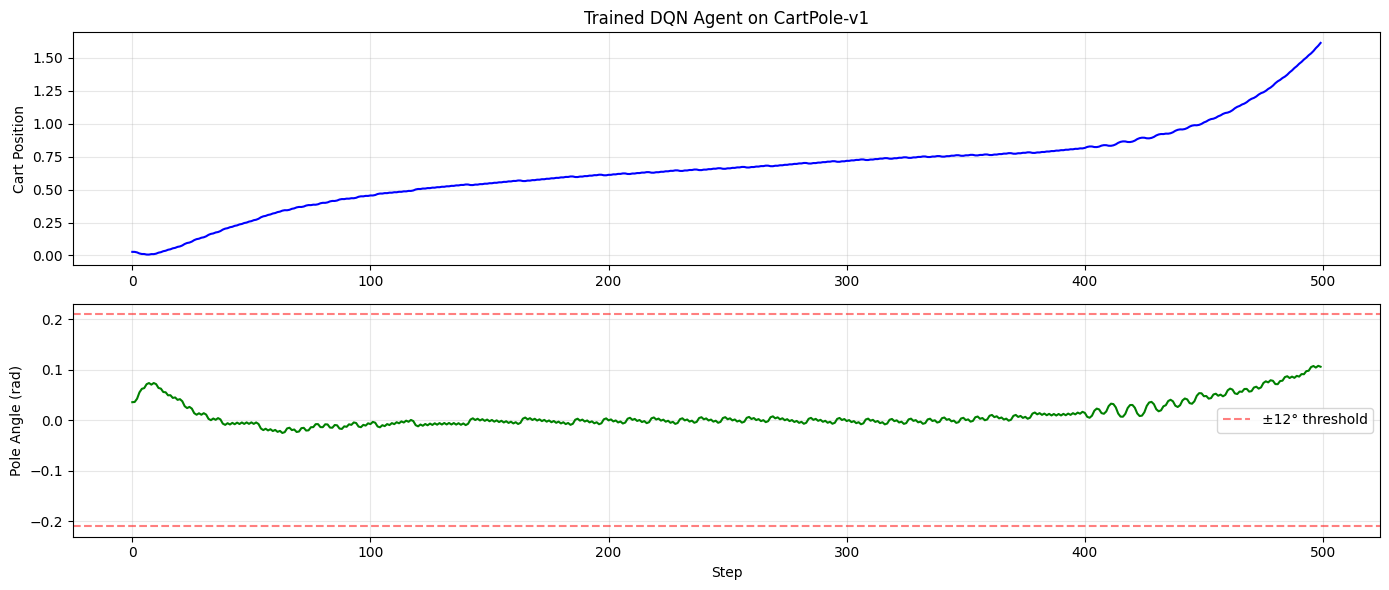

Total reward: 500
Final cart position: 1.612
Max pole angle: 0.1078 rad (6.2°)


In [14]:
env = gym.make(ENV_NAME)
state, _ = env.reset(seed=42)
positions = []
angles = []
rewards = []

with torch.no_grad():
    for step in range(max_steps):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        action = q_values.argmax(dim=1).item()

        positions.append(state[0])
        angles.append(state[2])
        rewards.append(1)

        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

env.close()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
ax1.plot(positions, color='blue')
ax1.set_ylabel('Cart Position')
ax1.set_title('Trained DQN Agent on CartPole-v1')
ax1.grid(True, alpha=0.3)

ax2.plot(angles, color='green')
ax2.axhline(y=0.2094, color='red', linestyle='--', alpha=0.5, label='±12° threshold')
ax2.axhline(y=-0.2094, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Pole Angle (rad)')
ax2.set_xlabel('Step')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Total reward: {len(rewards)}')
print(f'Final cart position: {positions[-1]:.3f}')
print(f'Max pole angle: {max(abs(a) for a in angles):.4f} rad ({max(abs(a) for a in angles)*180/np.pi:.1f}°)')

## 15. Summary### What we built- A **Q-Network** (MLP) that approximates Q(s, a) for all actions from a 4-dim CartPole state- An **experience replay buffer** that stores transitions and samples random minibatches to decorrelate training- A **target network** — a frozen copy of the Q-network updated every 100 steps for stable training targets- **ε-greedy exploration** with exponential decay from 1.0 to 0.01- The **full DQN training loop** (Algorithm 1 from the paper) with Huber Q-learning loss### Key components from the paper| Component | Paper (Atari) | This notebook (CartPole) ||-----------|---------------|--------------------------|| Q-network | CNN (3 conv + 2 FC) | MLP (2 hidden layers) || Input | 84×84×4 pixels | 4-dim state vector || Replay buffer | 1,000,000 transitions | 10,000 transitions || Target update | Every 10,000 steps | Every 100 steps || Loss | Huber (SmoothL1) | Huber (SmoothL1) || Actions | 4–18 per game | 2 (left/right) || Algorithm | Identical | Identical |### Paper fidelity- ✅ Experience replay with random minibatch sampling- ✅ Target network with periodic hard-copy updates- ✅ ε-greedy exploration with decay- ✅ Huber loss (SmoothL1) — used in the Nature DQN paper- ✅ Gradient norm clipping for stability- ⚠️ MLP instead of CNN (appropriate for low-dimensional state)- ⚠️ Smaller buffer and more frequent target updates (appropriate for CartPole scale)### InfluenceThis paper launched the field of deep reinforcement learning. Its core techniques — experience replay and target networks — remain standard in modern value-based RL. Direct descendants include Double DQN, Dueling DQN, Prioritized Replay, Rainbow, and the DeepMind lineage of AlphaGo, AlphaZero, and MuZero.